# Análisis de la Tasa de Excepción para un Período Específico
Este notebook visualiza la tasa de excepción diaria para el período del 15 de marzo al 1 de abril de 2025.

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

# Constantes de visualización
FIG_SIZE = (14, 7)
TITLE_FONT_SIZE = 16
FONT_SIZE = 12
DPI = 150

In [26]:
# Cargar los datos
daily_summary = pd.read_parquet('../clean_data/avg_global.parquet')

# Asegurarse de que el índice es de tipo datetime para poder filtrar por fecha
if not isinstance(daily_summary.index, pd.DatetimeIndex):
    daily_summary.index = pd.to_datetime(daily_summary.index)

In [27]:
# Definir el rango de fechas de interés
start_date = '2025-03-15'
end_date = '2025-04-01'

# Filtrar el DataFrame para el período especificado
filtered_series = daily_summary.loc[start_date:end_date, 'tasa_excepcion']

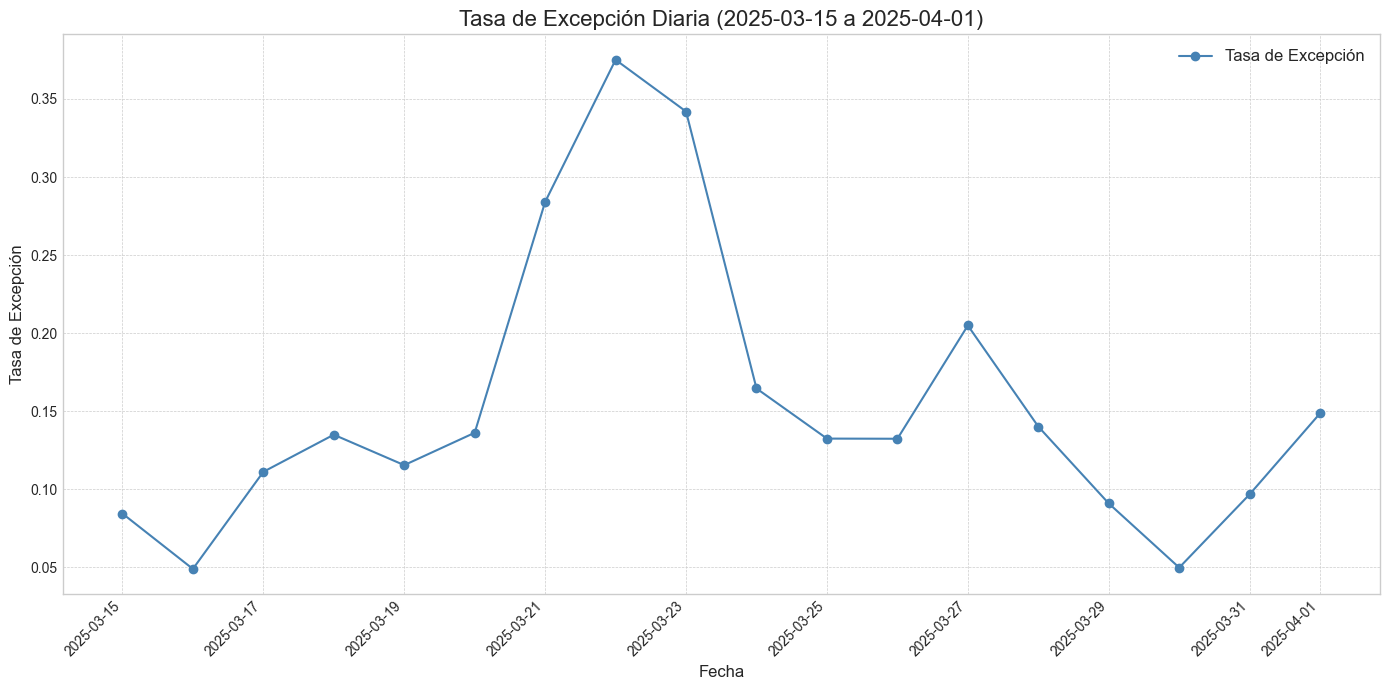

In [28]:
# Crear la visualización
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=FIG_SIZE)

# Graficar la serie de tiempo filtrada
ax.plot(filtered_series.index, filtered_series.values, marker='o', linestyle='-', color='steelblue', label='Tasa de Excepción')

# Configurar el título y las etiquetas
ax.set_title(f'Tasa de Excepción Diaria ({start_date} a {end_date})', fontsize=TITLE_FONT_SIZE)
ax.set_xlabel('Fecha', fontsize=FONT_SIZE)
ax.set_ylabel('Tasa de Excepción', fontsize=FONT_SIZE)

# Mejorar la legibilidad del eje x
plt.xticks(rotation=45, ha='right')

# Añadir una leyenda y una cuadrícula
ax.legend(fontsize=FONT_SIZE)
ax.grid(True, which='both', linestyle='--', linewidth=0.5)

# Ajustar el layout y mostrar el gráfico
plt.tight_layout()
plt.show()

### Análisis de Fallos por Robot y Razón de Excepción

In [29]:
# Cargar los datos no agregados
process_robot_df = pd.read_parquet('../clean_data/process_robot.parquet')
semi_raw_df = pd.read_parquet('../clean_data/semi_raw.parquet')

# Asegurarse de que los índices son de tipo datetime
if not isinstance(process_robot_df.index, pd.DatetimeIndex):
    process_robot_df.index = pd.to_datetime(process_robot_df.index)

if 'Loaded' in semi_raw_df.columns and not pd.api.types.is_datetime64_any_dtype(semi_raw_df['Loaded']):
    semi_raw_df['Loaded'] = pd.to_datetime(semi_raw_df['Loaded'])

In [30]:
# Definir el período de análisis
start_date_analysis = '2025-03-20'
end_date_analysis = '2025-03-24'

# Filtrar `process_robot_df` por el rango de fechas
exceptions_by_robot = process_robot_df.loc[start_date_analysis:end_date_analysis]

# Calcular el número de excepciones
exceptions_by_robot['exception_count'] = exceptions_by_robot['entries'] * exceptions_by_robot['tasa_excepcion']

# Agrupar por robot y sumar las excepciones
failed_robots = exceptions_by_robot.groupby('UserRobot')['exception_count'].sum().sort_values(ascending=False)

print("Ranking de robots con más excepciones (20-24 de marzo):")
print(failed_robots)

Ranking de robots con más excepciones (20-24 de marzo):
UserRobot
XXXX6050    3309.0
XXXX3500    1024.0
XXXX9820     447.0
XXXX5090     371.0
XXXX8730     195.0
             ...  
XXXX1580       0.0
XXXX1990       0.0
XXXX5620       0.0
XXXX6010       0.0
XXXX1830       0.0
Name: exception_count, Length: 96, dtype: float64


C:\Users\santi\AppData\Local\Temp\ipykernel_3432\3244066736.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  exceptions_by_robot['exception_count'] = exceptions_by_robot['entries'] * exceptions_by_robot['tasa_excepcion']


In [31]:
# Filtrar `semi_raw_df` para el mismo período y solo para transacciones con excepción
failed_transactions = semi_raw_df[
    (semi_raw_df['Loaded'].dt.date >= pd.to_datetime(start_date_analysis).date()) &
    (semi_raw_df['Loaded'].dt.date <= pd.to_datetime(end_date_analysis).date()) &
    (semi_raw_df['FinishStatus'] == 'Exception')
]

# Analizar las razones de las excepciones para los robots con más fallos
if not failed_robots.empty:
    top_robot = failed_robots.index[0]
    print(f"\nAnálisis de excepciones para el robot con más fallos: {top_robot}")
    
    robot_exceptions = failed_transactions[failed_transactions['UserRobot'] == top_robot]
    exception_reasons = robot_exceptions['ExceptionReason'].value_counts()
    
    print("\nRazones de excepción más comunes:")
    print(exception_reasons)
else:
    print("\nNo se encontraron excepciones en el período especificado.")



Análisis de excepciones para el robot con más fallos: XXXX6050

Razones de excepción más comunes:
ExceptionReason
Cuenta ya se encuentra suspendida                                                                                    231
error al encontrar el campo username en la pagina de inicio de IDG                                                   147
Cliente sin cuenta activa vigente. Mensaje IDG: 5205139: Unable to find a user for user name or alias 772191626.      16
No tiene Tokens para eliminar con el filtro TokenSet =  SFTK_PER  o State =  Current r                                14
Cliente sin cuenta activa vigente. Mensaje IDG: 5205139: Unable to find a user for user name or alias 275609110.      14
                                                                                                                    ... 
Cliente sin cuenta activa vigente. Mensaje IDG: 5205139: Unable to find a user for user name or alias 88090543. M      1
Cliente sin cuenta activa vigente. Men

### Análisis de Fallos por Proceso

In [32]:
# Agrupar por nombre de proceso y sumar las excepciones
failed_processes = exceptions_by_robot.groupby('ProcessName')['exception_count'].sum().sort_values(ascending=False)

print("Ranking de procesos con más excepciones (20-24 de marzo):")
print(failed_processes)

if not failed_processes.empty:
    top_process = failed_processes.index[0]
    print(f"\nEl proceso con más fallos es: {top_process}")
else:
    print("\nNo se encontraron excepciones en el período especificado para analizar procesos.")

Ranking de procesos con más excepciones (20-24 de marzo):
ProcessName
CIBFRA_FRAU_BLQTEF          3309.0
COAML_AML_ESTADO            1024.0
PRODMIN_COME_NOTFACT_NOT     428.0
OPMIN_PROD_CWREFRENV2        371.0
TI_ROBOTIC_UPDOWNS3          195.0
                             ...  
OPMIN_CDO_PAGRELP_PRECA        0.0
OPMIN_CDO_FORREM               0.0
OPMIN_TARJ_CARHIS              0.0
OPMIN_CDO_FACILWEB             0.0
OPMIN_TARJ_CAMDIRE             0.0
Name: exception_count, Length: 92, dtype: float64

El proceso con más fallos es: CIBFRA_FRAU_BLQTEF


### Análisis de Razones para el Proceso con más Fallos

In [33]:
# Analizar las razones de las excepciones para el proceso con más fallos
if not failed_processes.empty:
    top_process_name = failed_processes.index[0]
    print(f"\nAnálisis de excepciones para el proceso con más fallos: {top_process_name}")
    
    # Filtrar las transacciones fallidas para el proceso principal
    process_exceptions = failed_transactions[failed_transactions['ProcessName'] == top_process_name]
    
    # Contar las razones de excepción
    process_exception_reasons = process_exceptions['ExceptionReason'].value_counts()
    
    print("\nRazones de excepción más comunes para este proceso:")
    print(process_exception_reasons)
else:
    print("\nNo se encontraron excepciones para analizar las razones de los procesos.")


Análisis de excepciones para el proceso con más fallos: CIBFRA_FRAU_BLQTEF

Razones de excepción más comunes para este proceso:
ExceptionReason
Cuenta ya se encuentra suspendida                                                                                    231
error al encontrar el campo username en la pagina de inicio de IDG                                                   147
Cliente sin cuenta activa vigente. Mensaje IDG: 5205139: Unable to find a user for user name or alias 772191626.      16
No tiene Tokens para eliminar con el filtro TokenSet =  SFTK_PER  o State =  Current r                                14
Cliente sin cuenta activa vigente. Mensaje IDG: 5205139: Unable to find a user for user name or alias 275609110.      14
                                                                                                                    ... 
Cliente sin cuenta activa vigente. Mensaje IDG: 5205139: Unable to find a user for user name or alias 88090543. M      1
Cliente 

### Análisis de Fallos del 8 al 12 de Marzo

In [34]:
# Definir el nuevo período de análisis
start_date_new = '2025-03-08'
end_date_new = '2025-03-12'

# Filtrar `process_robot_df` por el nuevo rango de fechas
exceptions_by_robot_new = process_robot_df.loc[start_date_new:end_date_new].copy()

# Calcular el número de excepciones
exceptions_by_robot_new['exception_count'] = exceptions_by_robot_new['entries'] * exceptions_by_robot_new['tasa_excepcion']

# Agrupar por robot y sumar las excepciones
failed_robots_new = exceptions_by_robot_new.groupby('UserRobot')['exception_count'].sum().sort_values(ascending=False)

print(f"Ranking de robots con más excepciones ({start_date_new} al {end_date_new}):")
print(failed_robots_new)

# Agrupar por proceso y sumar las excepciones
failed_processes_new = exceptions_by_robot_new.groupby('ProcessName')['exception_count'].sum().sort_values(ascending=False)

print(f"\nRanking de procesos con más excepciones ({start_date_new} al {end_date_new}):")
print(failed_processes_new)

Ranking de robots con más excepciones (2025-03-08 al 2025-03-12):
UserRobot
XXXX3500    4208.0
XXXX4880    1282.0
XXXX5090     563.0
XXXX9820     527.0
XXXX8730     204.0
             ...  
XXXX0570       0.0
XXXX5020       0.0
XXXX0080       0.0
XXXX0620       0.0
XXXX3390       0.0
Name: exception_count, Length: 98, dtype: float64

Ranking de procesos con más excepciones (2025-03-08 al 2025-03-12):
ProcessName
COAML_AML_ESTADO            4208.0
LEG_FIS_SPF                 1282.0
OPMIN_PROD_CWREFRENV2        563.0
PRODMIN_COME_NOTFACT_NOT     511.0
COAML_AML_UBOCU              229.0
                             ...  
OPMIN_REM_FICHACONV            0.0
OPMIN_REM_FICHAMP              0.0
OPMIN_REM_FNAUT                0.0
OPMIN_TARJ_CARHIS              0.0
CIBFRA_CIBER_ABIF              0.0
Name: exception_count, Length: 93, dtype: float64


In [35]:
# Filtrar `semi_raw_df` para el nuevo período y solo para transacciones con excepción
failed_transactions_new = semi_raw_df[
    (semi_raw_df['Loaded'].dt.date >= pd.to_datetime(start_date_new).date()) &
    (semi_raw_df['Loaded'].dt.date <= pd.to_datetime(end_date_new).date()) &
    (semi_raw_df['FinishStatus'] == 'Exception')
]

# Analizar las razones de las excepciones para el robot con más fallos
if not failed_robots_new.empty:
    top_robot_new = failed_robots_new.index[0]
    print(f"\nAnálisis de excepciones para el robot con más fallos ({top_robot_new}):")
    
    robot_exceptions_new = failed_transactions_new[failed_transactions_new['UserRobot'] == top_robot_new]
    exception_reasons_robot_new = robot_exceptions_new['ExceptionReason'].value_counts()
    
    print("\nRazones de excepción más comunes:")
    print(exception_reasons_robot_new)
else:
    print("\nNo se encontraron excepciones de robots en el período especificado.")

# Analizar las razones de las excepciones para el proceso con más fallos
if not failed_processes_new.empty:
    top_process_new = failed_processes_new.index[0]
    print(f"\nAnálisis de excepciones para el proceso con más fallos ({top_process_new}):")
    
    process_exceptions_new = failed_transactions_new[failed_transactions_new['ProcessName'] == top_process_new]
    exception_reasons_process_new = process_exceptions_new['ExceptionReason'].value_counts()
    
    print("\nRazones de excepción más comunes para este proceso:")
    print(exception_reasons_process_new)
else:
    print("\nNo se encontraron excepciones de procesos en el período especificado.")


Análisis de excepciones para el robot con más fallos (XXXX3500):

Razones de excepción más comunes:
ExceptionReason
El Estado Formulario M no es un estado valido para MODIFICAR                                                          940
Número Cliente no existe en Base de Datos para el rut:0000218375421, este dato es requerido en el flujo de negocio      1
Número Cliente no existe en Base de Datos para el rut:0000217650933, este dato es requerido en el flujo de negocio      1
Número Cliente no existe en Base de Datos para el rut:000021772046K, este dato es requerido en el flujo de negocio      1
Número Cliente no existe en Base de Datos para el rut:0000217747155, este dato es requerido en el flujo de negocio      1
                                                                                                                     ... 
Número Cliente no existe en Base de Datos para el rut:000006008985K, este dato es requerido en el flujo de negocio      1
Número Cliente no existe en B